# 2 — Time adjustments

**Theme:** getting a record onto the time base you need.

Instruments log on their own clocks and at their own intervals. These four
operations — crop, shift, smooth and rebin — are what you use to line them up
before comparing or combining anything.

Plots here are only used to show the effect of each step; the plotting API
itself is covered in [5 — Plotting](05-plotting.ipynb).

In [1]:
import matplotlib.pyplot as plt

import aerosoltools as at

ops = at.load_data_from_folder(
    "../../tests/data/OPS_data", at.load_ops_file, search_word="OPS"
)
print(f"{len(ops.data)} rows, {ops.time[0]} -> {ops.time[-1]}")

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading files:   0%|          | 0/4 [00:00<?, ?file/s]

Loading files: 100%|██████████| 4/4 [00:00<00:00, 113.28file/s]


File load summary:

+---------------+--------+--------+
|     File      | Status | Reason |
+---------------+--------+--------+
| OPS_data1.csv | Loaded |   -    |
| OPS_data2.csv | Loaded |   -    |
| OPS_data3.csv | Loaded |   -    |
| OPS_data4.csv | Loaded |   -    |
+---------------+--------+--------+
2223 rows, 2023-10-25 08:59:51 -> 2023-10-31 14:06:52


The record spans several days. Each operation below modifies the object **in
place** by default; pass `inplace=False` to get a modified copy instead and
leave the original alone.

## Cropping

`timecrop` restricts the record to an interval. With `focus=False` it does the
opposite and removes the interval.

In [2]:
ops.timecrop(start="2023-10-25 08:00:00", end="2023-10-26 22:00:00")
print(f"{len(ops.data)} rows, {ops.time[0]} -> {ops.time[-1]}")

2079 rows, 2023-10-25 08:59:51 -> 2023-10-26 19:38:42


## Shifting

`timeshift` moves every timestamp by a fixed offset — the usual fix when an
instrument's clock was set wrong, or was in another time zone.

In [3]:
first_before = ops.time[0]
ops.timeshift(minutes=120)
print(f"{first_before}  ->  {ops.time[0]}")

2023-10-25 08:59:51  ->  2023-10-25 10:59:51


## Smoothing

`timesmooth` applies a rolling window. It changes the values but **not** the
number of samples or the timestamps.

In [4]:
smoothed = ops.timesmooth(60, method="mean", inplace=False)
print(f"rows unchanged: {len(ops.data)} -> {len(smoothed.data)}")

rows unchanged: 2079 -> 2079


## Rebinning

`timerebin` is the one that changes the time base: it resamples onto a regular
grid, so the number of samples changes.

In [5]:
rebinned = ops.timerebin("2.5h", inplace=False)
print(f"{len(ops.data)} rows -> {len(rebinned.data)} rows at 2.5 h")

2079 rows -> 15 rows at 2.5 h


Rebinning to a **common** frequency is how two instruments logging at different
intervals are made comparable. Several functions do this for you when asked —
`plot_correlation` and the calibration helpers take `match="rebin"` — but doing
it explicitly is useful when you want the same grid everywhere.

## The effect of each step

Loading files:   0%|          | 0/4 [00:00<?, ?file/s]

Loading files: 100%|██████████| 4/4 [00:00<00:00, 126.15file/s]


File load summary:

+---------------+--------+--------+
|     File      | Status | Reason |
+---------------+--------+--------+
| OPS_data1.csv | Loaded |   -    |
| OPS_data2.csv | Loaded |   -    |
| OPS_data3.csv | Loaded |   -    |
| OPS_data4.csv | Loaded |   -    |
+---------------+--------+--------+


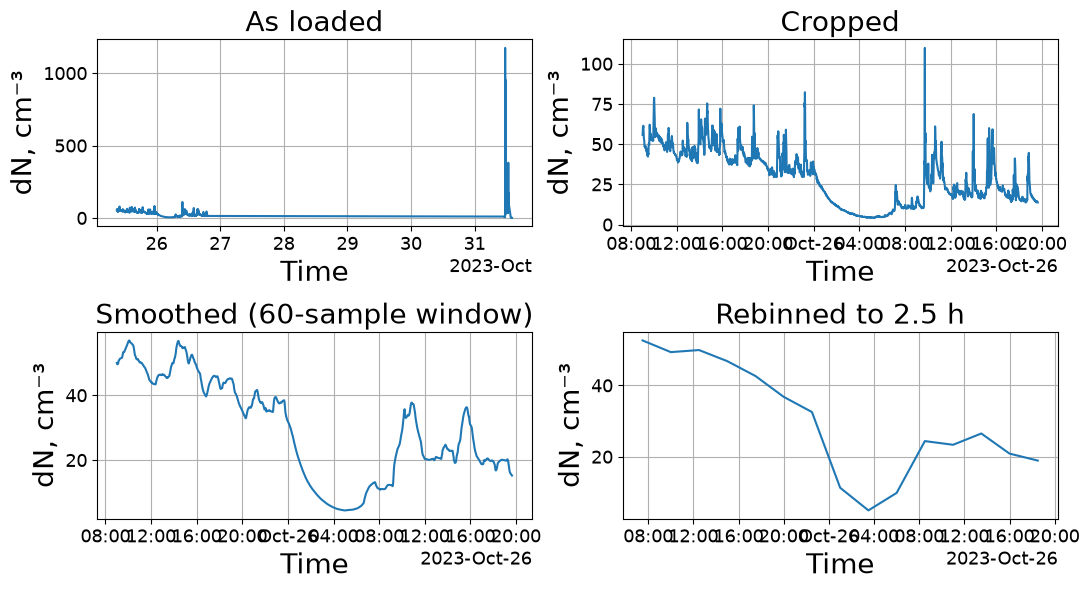

In [6]:
source = at.load_data_from_folder(
    "../../tests/data/OPS_data", at.load_ops_file, search_word="OPS"
)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(11, 6))

source.plot_total_conc(axs[0, 0])
axs[0, 0].set_title("As loaded")

step = source.copy_self()
step.timecrop(start="2023-10-25 08:00:00", end="2023-10-26 22:00:00")
step.plot_total_conc(axs[0, 1])
axs[0, 1].set_title("Cropped")

step.timesmooth(60, method="mean")
step.plot_total_conc(axs[1, 0])
axs[1, 0].set_title("Smoothed (60-sample window)")

step.timerebin("2.5h")
step.plot_total_conc(axs[1, 1])
axs[1, 1].set_title("Rebinned to 2.5 h")

plt.tight_layout()

Smoothing flattens the peaks while keeping every sample; rebinning replaces the
samples with far fewer, wider ones. Both reduce noise, but only rebinning
changes what a "sample" means — which matters for any statistic computed
afterwards.

## Irregular sampling

Real records have gaps and jitter. Integrated quantities (time-weighted
averages, exposure metrics) account for the actual spacing between samples
rather than assuming a fixed interval, so an instrument that paused for ten
minutes does not silently distort the result.

---

**Next:** [3 — Activities](03-activities.ipynb) marks *what was happening* during
a record.